In [1]:
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, balanced_accuracy_score, accuracy_score
import glob
import os
import numpy as np

# ===========================================================
# Load label corrections
# ===========================================================
def load_corrections(corrections_path):
    df = pd.read_csv(corrections_path)
    label_map = {'G': 1, 'U': 0}
    df['Id'] = df['Id'].str.replace('.jpg', '', regex=False).str.strip()
    corrections = dict(zip(df['Id'].astype(int), df['New label'].map(label_map)))
    print("Sample correction keys:", list(corrections.keys())[:5])
    print("Key type:", type(list(corrections.keys())[0]))
    return corrections


# ===========================================================
# Load predictions from a CSV file
# ===========================================================
def load_predictions(file_path, type_model="single", corrections=None):
    df = pd.read_csv(file_path)

    if 'y_true' in df.columns and 'y_prob_pos' in df.columns:
        y_true = df['y_true'].values.copy()
        y_prob = df['y_prob_pos'].values.copy()
        id_col = 'id'
    elif 'true_label' in df.columns and 'prob_class_1' in df.columns:
        y_true = df['true_label'].values.copy()
        y_prob = df['prob_class_1'].values.copy()
        id_col = 'image_id'
    else:
        raise ValueError(f"Unknown column format in {file_path}. Columns: {df.columns.tolist()}")

    if corrections and id_col in df.columns:
        corrected = df[id_col].map(corrections)
        mask = corrected.notna() & (corrected.values != y_true)
        n_changed = mask.sum()
        y_true[mask] = corrected[mask].astype(y_true.dtype)
        print(f"  [{os.path.basename(file_path)}] Labels changed: {n_changed} / {len(y_true)}")

    return y_true, y_prob


# ===========================================================
# Load predictions and invert class labels + probabilities
# ===========================================================
def load_and_invert(file_path, type_model="single", corrections=None):
    y_true, y_prob = load_predictions(file_path, type_model=type_model, corrections=corrections)
    y_true = 1 - y_true
    y_prob = 1 - y_prob
    return y_true, y_prob


# ===========================================================
# Compute selected metrics
# ===========================================================
def compute_all_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    auc         = roc_auc_score(y_true, y_prob)
    f1          = f1_score(y_true, y_pred, zero_division=0)
    bal_acc     = balanced_accuracy_score(y_true, y_pred)
    acc         = accuracy_score(y_true, y_pred)

    return {
        "Sensitivity": round(sensitivity, 4),
        "Specificity": round(specificity, 4),
        "AUC":         round(auc, 4),
        "F1":          round(f1, 4),
        "Bal_Acc":     round(bal_acc, 4),
        "Accuracy":    round(acc, 4),
        "TP":          int(tp),
        "TN":          int(tn),
        "FP":          int(fp),
        "FN":          int(fn),
    }

Sample correction keys: [605367, 617557, 626306, 629433, 636595]
Key type: <class 'int'>
  [predictions_model_1_calibration.csv] Labels changed: 11 / 825
  [predictions_model_2_calibration.csv] Labels changed: 11 / 825
  [predictions_model_3_calibration.csv] Labels changed: 11 / 825
  [predictions_model_4_calibration.csv] Labels changed: 11 / 825
  [predictions_model_5_calibration.csv] Labels changed: 11 / 825
  [ensemble_average.csv] Labels changed: 11 / 825
[SAVED] /projects/retprogression/rgarridogarcia/calibration_plots/test_split/calibration_avg_Test Set 1.png


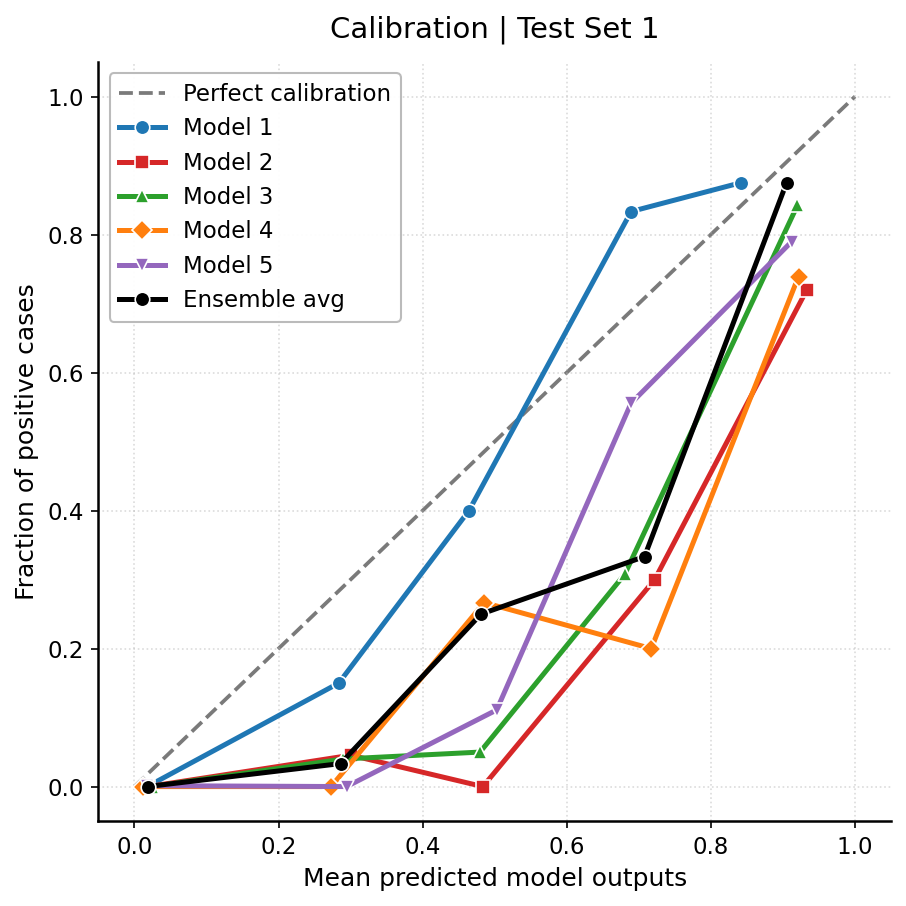

  [predictions_model_1_validation.csv] Labels changed: 9 / 826
  [predictions_model_2_validation.csv] Labels changed: 9 / 826
  [predictions_model_3_validation.csv] Labels changed: 9 / 826
  [predictions_model_4_validation.csv] Labels changed: 9 / 826
  [predictions_model_5_validation.csv] Labels changed: 9 / 826
  [ensemble_average.csv] Labels changed: 9 / 826
[SAVED] /projects/retprogression/rgarridogarcia/calibration_plots/test_split/calibration_avg_Test Set 2.png


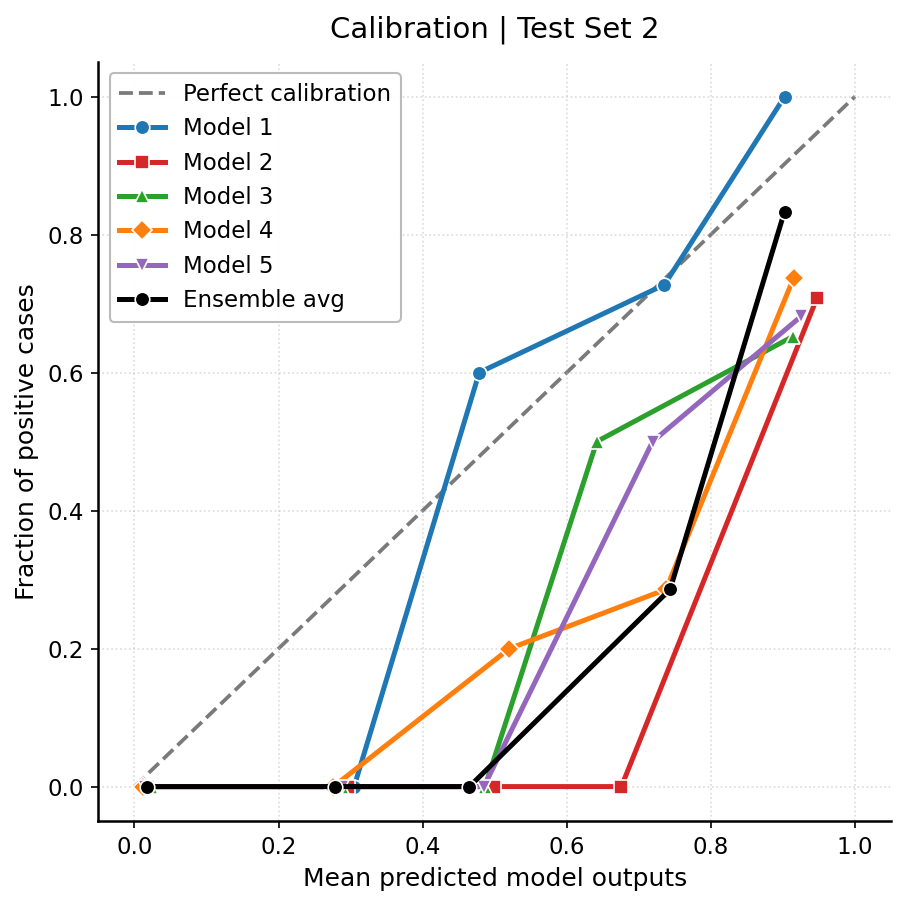

In [2]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve

# ===========================================================
# Config
# ===========================================================
THRESHOLD = 0.5
N_BINS    = 5
STRATEGY  = "uniform"
SAVE_DIR  = Path("/projects/retprogression/rgarridogarcia/calibration_plots")

SPLITS = {
    "test_split": {
        "base":         "/projects/retprogression/rgarridogarcia/test_split",
        "ensemble_cal": "/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_average.csv",
        "ensemble_val": "/projects/retprogression/rgarridogarcia/ensemble/ensemble_validation_half_split/ensemble_average.csv",
    },
}

CORRECTIONS = load_corrections("/projects/retprogression/rgarridogarcia/Gradable_test_relabeling.csv")


# ===========================================================
# Style
# ===========================================================
def _set_publication_style():
    plt.rcParams.update({
        "figure.dpi":           150,
        "savefig.dpi":          600,
        "savefig.bbox":         "tight",
        "savefig.transparent":  False,
        "font.family":          "sans-serif",
        "font.sans-serif":      ["DejaVu Sans", "Arial", "Helvetica"],
        "font.size":            12,
        "axes.titlesize":       14,
        "axes.titleweight":     "normal",
        "axes.labelsize":       12,
        "axes.labelweight":     "normal",
        "axes.linewidth":       1.2,
        "xtick.labelsize":      11,
        "ytick.labelsize":      11,
        "legend.fontsize":      11,
        "legend.frameon":       True,
        "legend.framealpha":    0.95,
        "legend.edgecolor":     "#B8B8B8",
        "axes.spines.top":      False,
        "axes.spines.right":    False,
    })


# ===========================================================
# Calibration plot helpers
# ===========================================================
COLORS = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#9467bd"]
MARKERS = ["o", "s", "^", "D", "v"]

def plot_calibration(
    curves: list[dict],   # [{"label": str, "y_true": array, "y_prob": array}, ...]
    title: str,
    save_path: Path | None = None,
    n_bins: int = N_BINS,
    strategy: str = STRATEGY,
    show: bool = True,
):
    """
    Plot calibration curves for multiple models/ensembles on one axes.

    Parameters
    ----------
    curves     : list of dicts with keys "label", "y_true", "y_prob"
    title      : axes title
    save_path  : if given, save figure here
    """
    _set_publication_style()
    fig, ax = plt.subplots(figsize=(6.2, 6.2))

    # Perfect calibration reference line
    ax.plot([0, 1], [0, 1], linestyle="--", color="#7A7A7A",
            linewidth=1.8, label="Perfect calibration", zorder=1)

    for idx, curve in enumerate(curves):
        frac_pos, mean_pred = calibration_curve(
            curve["y_true"], curve["y_prob"],
            n_bins=n_bins, strategy=strategy,
        )
        color = curve.get("color", COLORS[idx % len(COLORS)])
        ax.plot(
            mean_pred, frac_pos,
            marker=MARKERS[idx % len(MARKERS)],
            markersize=7,
            markeredgewidth=0.8,
            markeredgecolor="white",
            color=color,          # <-- was COLORS[idx % len(COLORS)]
            linewidth=2.4,
            label=curve["label"],
            zorder=2 + idx,
        )

    ax.set_xlabel("Mean predicted model outputs")
    ax.set_ylabel("Fraction of positive cases")
    ax.set_title(title, pad=12)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.45)
    ax.legend(loc="upper left")
    fig.tight_layout()

    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path)
        print(f"[SAVED] {save_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)


# ===========================================================
# Run — one plot per (split, subset) combining models + ensemble
# ===========================================================
for split_name, split_cfg in SPLITS.items():
    for subset in ("calibration", "validation"):

        curves = []

        # Individual models
        for i in range(1, 6):
            fp = f"{split_cfg['base']}/predictions_model_{i}_{subset}.csv"
            if not os.path.exists(fp):
                print(f"[MISSING] {fp}")
                continue
            yt, yp = load_and_invert(fp, corrections=CORRECTIONS)
            curves.append({"label": f"Model {i}", "y_true": yt, "y_prob": yp})

        # Ensemble
        ensemble_key = "ensemble_cal" if subset == "calibration" else "ensemble_val"
        ensemble_fp  = split_cfg[ensemble_key]
        if os.path.exists(ensemble_fp):
            yt, yp = load_and_invert(ensemble_fp, corrections=CORRECTIONS)
            curves.append({"label": "Ensemble avg", "y_true": yt, "y_prob": yp, "color": "#000000"})  # ✅ here
        else:
            print(f"[MISSING] {ensemble_fp}")

        if not curves:
            print(f"[SKIP] No data for {split_name} / {subset}")
            continue

        if subset == "calibration":
            test_n = "Test Set 1"
        if subset == "validation":
            test_n = "Test Set 2"
        save_path = SAVE_DIR / split_name / f"calibration_avg_{test_n}.png"
        plot_calibration(
            curves=curves,
            title=f"Calibration | {test_n}",
            save_path=save_path,
            show=True,
        )